#**Lung Disease Diagnosis**
# A multi class classification system using a transfer learning approach**


---



# Goal
It is important to make clear our goals. In emergency triage, it is far more costly missing a pneumonia or COVID case than a false alarm. THerefore we desire our primary objective to be focused on high diseas class sensitivity (recall) , over the overall accuracy. Despite this, THe accuracy will still be part of the overall analysis as it is still a very important metric.

<br><br>
This dataset is framed as a three-class classification problem: (1) Healthy, (2) COVID-19, (3) Pneumonia

# GPU Set Up + Google Drive Pairing

In [1]:
!pip install 'tensorflow[and-cuda]' matplotlib opencv-python pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 83.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.6.85
    Uninstalli

In [2]:
import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!nvidia-smi

Fri Jan 16 00:05:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dependency imports

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import Image
import os
import random
# from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import shutil

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

local_data_dir = "/content/Lung_Data"

# Data Preprocessing

Need to make sure that we try and preserve the images native features in order to avoid misleading the model.

Before, starting we load all of the data onto the local disk instead of on google drive cloud storage. It is extremely slow to load in from the drive for especially for the 1st epoch in training.

In [6]:
if not os.path.exists(local_data_dir):
  shutil.copytree("/content/drive/MyDrive/Machine Learning/Lung Data", local_data_dir)

## Exploratory Data Analysis (EDA & Sanity Checks)

Before model training, we visually inspect the dataset to verify image quality, class consistency, and preprocessing behaviour. These checks are used to inform design decisions but are **not part of the training pipeline.**


### Raw Image Property Inspection

We begin by examining basic image properties across the dataset, including spatial resolution and colour mode. This ensures that preprocessing choices are informed by the underlying data rather than assumed.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

data_dir = "/content/drive/MyDrive/Machine Learning/Lung Data/"
classes = ["COVID", "HEALTHY", "PNEUMONIA"]

all_sizes = []
modes = []

for cls in classes:
    class_dir = os.path.join(data_dir, cls)
    for f in os.listdir(class_dir)[:50]:  # sample 50 per class (adjust as needed)
        try:
            img = Image.open(os.path.join(class_dir, f))
            w, h = img.size
            all_sizes.append((w, h))
            modes.append(img.mode)
        except Exception as e:
            print(f"Error loading {f}: {e}")


print("Unique image modes:", set(modes))
print("Most common image sizes:", Counter(all_sizes).most_common(5))


Unique image modes: {'RGB', 'L'}
Most common image sizes: [((299, 299), 150)]


Observation:
- Images are split between single-channel ('L') grayscale and ('RGB') .
- Spatial resolutions are the same across samples.

Implication:
- Explicit channel handling is required for transfer learning.
- Images don't need to be resized for Xception.

### Raw Image Visual Inspection

We visually inspect a random subset of raw images across classes to verify image integrity and identify any obvious artefacts or inconsistencies.

* please bare in mind that this function using data variables from the next chapter, this was due to moving this over into this supplementary file. To get it to work, just run the other data preprocessing chapter and come back *

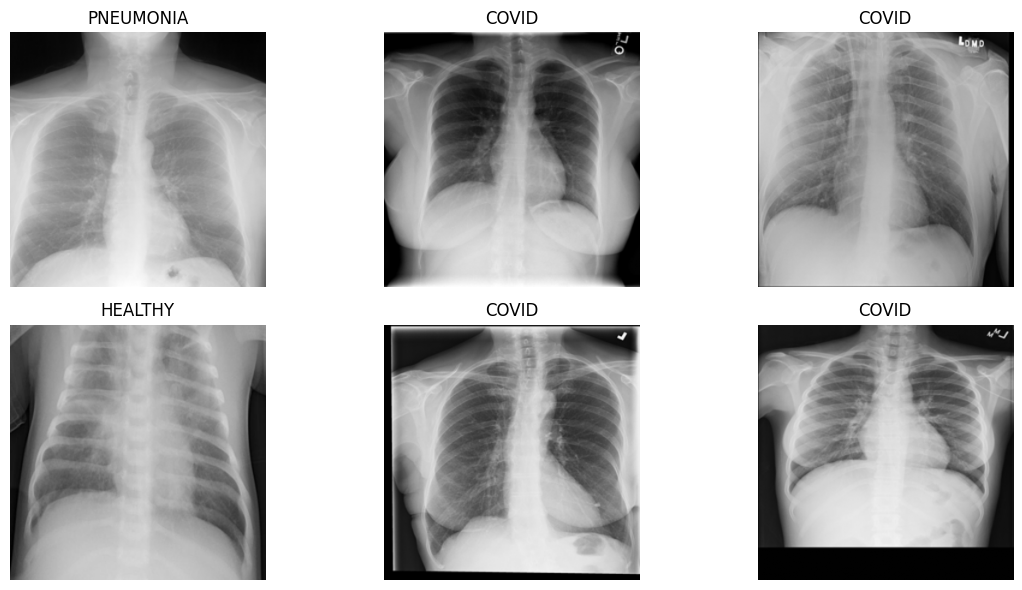

In [ ]:
def show_random_images(image_paths, labels, class_names, n=6):
    idxs = random.sample(range(len(image_paths)), n)
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(idxs):
        img = Image.open(image_paths[idx])
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

CLASS_NAMES = ["COVID", "HEALTHY", "PNEUMONIA"]

show_random_images(
    image_paths=X_train,
    labels=y_train,
    class_names=CLASS_NAMES,
    n=6
)

Observation:
- Lung fields are generally centred.
- No obviously corrupted or blank images are observed.

Implication:
- Dataset appears suitable for supervised learning without aggressive filtering.


### Preprocessing Strategy Definition

Based on the exploratory analysis above, a preprocessing pipeline is defined to preserve anatomical structure, standardise spatial resolution and ensure compatability with a pretrained Xception backbone

#### Final Preprocessing Function

In [ ]:
from tensorflow.keras.applications import xception

def preprocess_image(image, label, target_size=299, is_training=False):
    # Convert grayscale to RGB
    image = tf.image.grayscale_to_rgb(image)  # [H, W, 3]

    # Resize with padding to 299x299 (Xception's native input size)
    if image.shape[0] != target_size or image.shape[1] != target_size:
        image = tf.image.resize_with_pad(image,
                                         target_size,
                                         target_size,
                                         method='bilinear')


    # Convert to float32 and scale to [0, 255] (required by xception.preprocess_input)
    image = tf.cast(image, tf.float32)

    # Apply conservative augmentations
    if is_training:
        image = tf.image.random_brightness(image, max_delta=25.5)  # 10% of 255
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

        # Rotation: tf.image doesn't support rotation; use tf.keras.utils or custom
        # image = tf.keras.preprocessing.image.random_rotation(
        #     image.numpy(), rg=5.0, row_axis=0, col_axis=1, channel_axis=2, fill_mode='constant'
        # )

    # Apply Xception-specific preprocessing (scales to [-1, 1] internally)
    image = xception.preprocess_input(image)

    return image, label


# After full preprocessing (including xception.preprocess_input)
def full_preprocess(path):
    raw = tf.io.read_file(path)
    raw = tf.image.decode_image(raw, channels=1)
    raw = tf.cast(raw, tf.uint8)
    rgb = tf.image.grayscale_to_rgb(raw)
    resized = tf.image.resize_with_pad(rgb, 299, 299)
    resized = tf.cast(resized, tf.float32)
    final = xception.preprocess_input(resized)
    return final

sample = full_preprocess("/content/drive/MyDrive/Machine Learning/Lung Data/COVID/COVID (1).png")
print("Min pixel:", float(tf.reduce_min(sample)))
print("Max pixel:", float(tf.reduce_max(sample)))
# Should be ≈ -1.0 to 1.0

Min pixel: -0.7490196228027344
Max pixel: 0.8666666746139526


### Preprocessing Verification

we construct a small tensorflow dataset solely to verify that the preprocessing pipeline behaves as intended before integrating it into the training pipeline

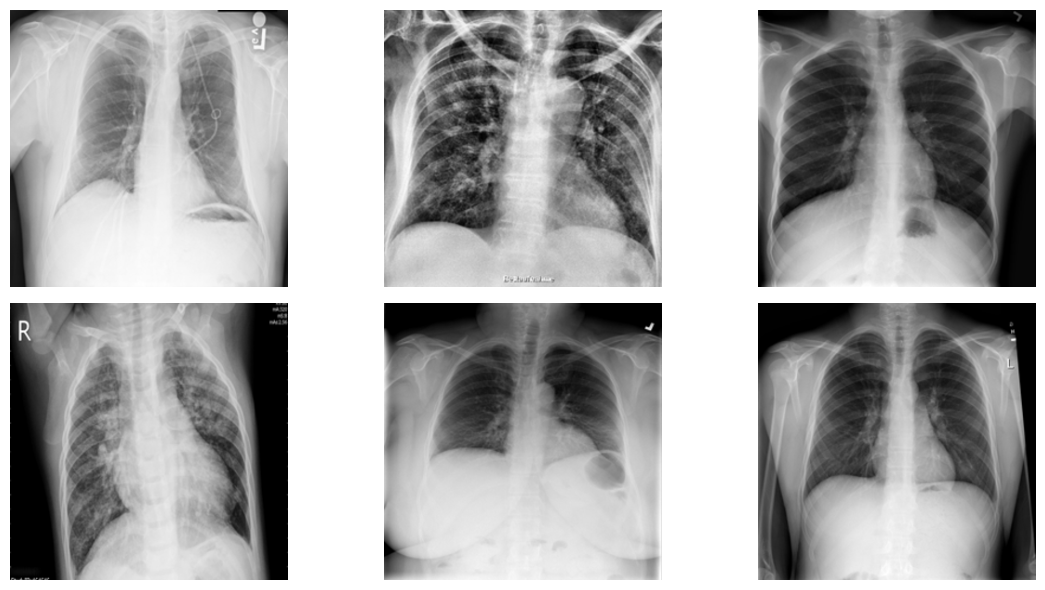

In [ ]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    return image, label


verify_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE) \
 .map(lambda x, y: preprocess_image(x, y, is_training=False),
      num_parallel_calls=tf.data.AUTOTUNE) \
 .batch(8)


def show_preprocessed_images(dataset, n=6):
    for images, labels in dataset.take(1):
        plt.figure(figsize=(12, 6))
        for i in range(n):
            img = images[i].numpy()
            img = (img - img.min()) / (img.max() - img.min())  # normalise for display
            plt.subplot(2, n // 2, i + 1)
            plt.imshow(img)
            plt.axis("off")
        plt.tight_layout()
        plt.show()


show_preprocessed_images(verify_ds)

Observation:
- Images are consistently resized to 299×299 with padding.
- Aspect ratios are preserved.
- Greyscale information is maintained across RGB channels.

Implication:
- The preprocessing pipeline behaves as intended and can be fixed for all experiments.



### Augmentation Sanity Check

A seperate verification dataset is used to confirm that training-time augmentation introduces only mild intensity variation and does not distort anatomical structure.

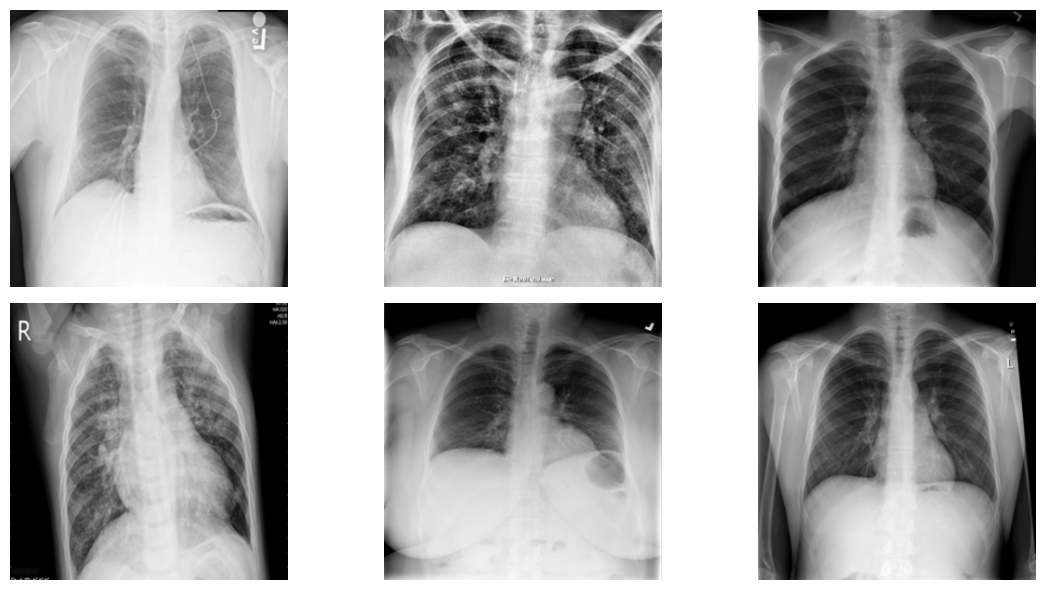

In [ ]:
augment_verify_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).map(load_image, num_parallel_calls=tf.data.AUTOTUNE) \
 .map(lambda x, y: preprocess_image(x, y, is_training=True),
      num_parallel_calls=tf.data.AUTOTUNE) \
 .batch(8)

show_preprocessed_images(augment_verify_ds)

 Observation:
- Brightness and contrast variations remain subtle.
- No geometric distortion or anatomical inversion is observed.

Implication:
- Intensity-based augmentation is suitable for chest X-ray classification.
- Spatial augmentations (rotation, flipping) are intentionally avoided.

### Preliminery Preprocessing Summary

Exploratory analysis and verification confirm that the final preprocessing pipeline:
- Is informed by image characteristics
- Preserves clinically relevant anatomical structure
- Is compatible with transfer learning using Xception
- Applies conservative augmentation during training only

This preprocessing configuration is fixed for all subsequent experiments to ensure fair and reproducible comparison.

## Official Pre-processing of Data

### Split Data Paths into training, validation and testing set

In [7]:
# Define paths and labels
data_dir = "/content/drive/MyDrive/Machine Learning/Lung Data/"
classes = ["HEALTHY", "PNEUMONIA", "COVID"]
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# Collect all file paths and labels
file_paths = []
labels = []

for cls in classes:
    cls_dir = os.path.join(local_data_dir, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_paths.append(os.path.join(cls_dir, fname))
            labels.append(class_to_idx[cls])

file_paths = np.array(file_paths)
labels = np.array(labels)

# Stratified split: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    file_paths, labels, test_size=0.15, stratify=labels, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765,  # ≈ 15% of total
    stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"class 0 -> 'HEALTHY',\nclass 1 -> 'PNEUMONIA',\nclass 2 -> 'COVID'")

Train: 10606, Val: 2274, Test: 2273
class 0 -> 'HEALTHY',
class 1 -> 'PNEUMONIA',
class 2 -> 'COVID'


### Visualise Class Stratified Datset Split

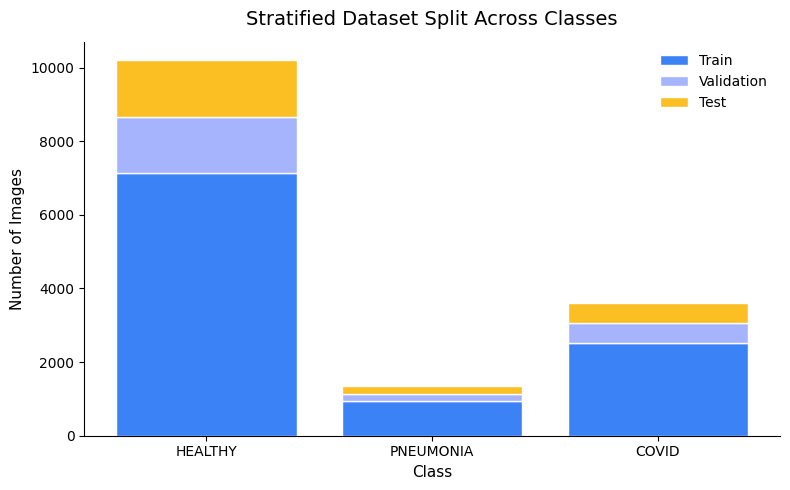

In [8]:
# --- Labels and sets ---
sets = {
    "Train": y_train,
    "Validation": y_val,
    "Test": y_test
}

classes = ["HEALTHY", "PNEUMONIA", "COVID"]
class_indices = {i: cls for i, cls in enumerate(classes)}

# --- Count samples per class per split ---
counts = {
    split: Counter(class_indices[label] for label in labels)
    for split, labels in sets.items()
}

# --- Prepare matrix ---
data = np.array([
    [counts["Train"][cls], counts["Validation"][cls], counts["Test"][cls]]
    for cls in classes
])

# --- Colors (calm, print-safe) ---
colors = ["#3B82F6", "#A5B4FC", "#FBBF24"]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(classes))

for i, (set_name, color) in enumerate(zip(sets.keys(), colors)):
    ax.bar(
        classes,
        data[:, i],
        bottom=bottom,
        label=set_name,
        color=color,
        edgecolor="white"
    )
    bottom += data[:, i]

# --- Styling ---
ax.set_title("Stratified Dataset Split Across Classes", fontsize=14, pad=12)
ax.set_ylabel("Number of Images", fontsize=11)
ax.set_xlabel("Class", fontsize=11)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


### Pre-processing Functions

In [9]:
from tensorflow.keras.applications import xception

def preprocess_image(image, label, target_size=299, is_training=False):
    # Convert grayscale to RGB
    image = tf.image.grayscale_to_rgb(image)  # [H, W, 3]

    # Resize with padding to 299x299 (Xception's native input size)
    if image.shape[0] != target_size or image.shape[1] != target_size:
        image = tf.image.resize_with_pad(image,
                                         target_size,
                                         target_size,
                                         method='bilinear')

    # Convert to float32 and scale to [0, 255] (required by xception.preprocess_input)
    image = tf.cast(image, tf.float32)

    if is_training:
        # Only apply to disease classes? → We'll handle that at dataset level (see below)
        image = tf.image.random_brightness(image, max_delta=25.5)  # 10% of 255
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # Apply Xception-specific preprocessing (scales to [-1, 1] internally)
    image = xception.preprocess_input(image)

    return image, label

def load_and_decode(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.ensure_shape(image, [None, None, 1])
    return image, label

### Adapt training, validation and testing Data

Change data from file path and class to a tensorflow compatible image data format

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 16  # Adjusted based on GPU memory (299x299 is large). 32 was not possible

# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = (train_ds
    .shuffle(buffer_size=len(X_train), seed=42, reshuffle_each_iteration=True)
    .map(load_and_decode, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: preprocess_image(x, y, target_size=299, is_training=True),
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Validation dataset (no augmentation)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = (val_ds
    .map(load_and_decode, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: preprocess_image(x, y, target_size=299, is_training=False),
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Test dataset (never augmented)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = (test_ds
    .map(load_and_decode, num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: preprocess_image(x, y, target_size=299, is_training=False),
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [11]:
# testing this worked
# Get one batch from training dataset
for batch in train_ds.take(1):
    x_batch, y_batch = batch
    print("Image batch shape:", x_batch.shape)
    print("Image dtype:", x_batch.dtype)
    print("Label batch shape:", y_batch.shape)
    print("Label dtype:", y_batch.dtype)
    print("first Label:", y_batch[0])

Image batch shape: (16, 299, 299, 3)
Image dtype: <dtype: 'float32'>
Label batch shape: (16,)
Label dtype: <dtype: 'int64'>
first Label: tf.Tensor(2, shape=(), dtype=int64)


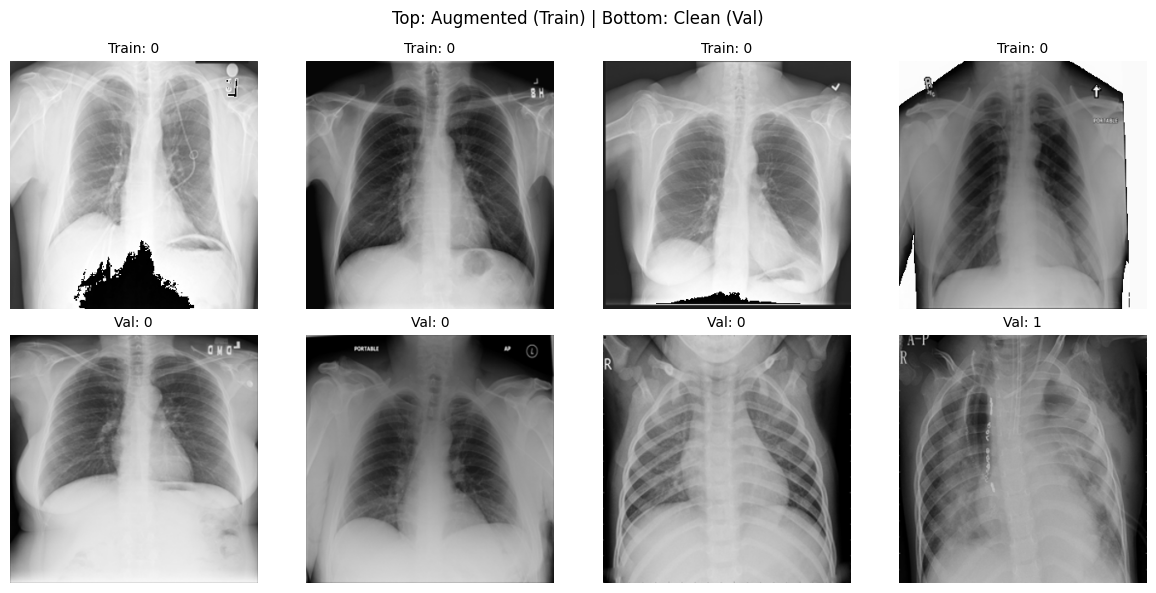

In [12]:
# Get a batch from TRAIN (with augmentation) and VAL (without)
train_batch = next(iter(train_ds))
val_batch = next(iter(val_ds))

# De-normalize Xception output for visualization
# xception.preprocess_input does: (x / 127.5) - 1 → so reverse it
def deprocess_xception(img):
    return (img + 1) * 127.5  # back to [0, 255]

# Plot 4 samples from train (augmented) and val (clean)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    # Training (augmented)
    img_train = deprocess_xception(train_batch[0][i].numpy()).astype('uint8')
    axes[0, i].imshow(img_train)
    axes[0, i].set_title(f"Train: {train_batch[1][i].numpy()}", fontsize=10)
    axes[0, i].axis('off')

    # Validation (no augmentation)
    img_val = deprocess_xception(val_batch[0][i].numpy()).astype('uint8')
    axes[1, i].imshow(img_val)
    axes[1, i].set_title(f"Val: {val_batch[1][i].numpy()}", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Top: Augmented (Train) | Bottom: Clean (Val)")
plt.tight_layout()
plt.show()

###

# Hyperparameter Tuning & Experimental Optimisation & Overall Model Training

## Imports

In [13]:
from sklearn.metrics import classification_report
import tensorflow as tf
import time
import json
import pandas as pd

## Re-runnable Functions

In [14]:
# setup tensorboard_cb to display the model using Tensorboard
root_logdir = os.path.join(os.curdir, "my_logs_4_comparison")

def get_comparisonrun_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

def build_xception_model(num_classes=3):
    base_model = tf.keras.applications.Xception(
        weights="imagenet",
        include_top=False,
        input_shape=(299, 299, 3)
    )

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(
        inputs=base_model.input,
        outputs=outputs
    )
    return model, base_model

def compute_unfreeze_index(base_model, percent):
    if percent == 1.0:
        return 0  # unfreeze all
    return int(len(base_model.layers) * (1 - percent))

def set_trainable_layers(base_model, unfreeze_from=None):
    if unfreeze_from is None:
        base_model.trainable = False
    else:
        unfreeze_from = compute_unfreeze_index(base_model, unfreeze_from)
        for layer in base_model.layers[:unfreeze_from]:
            layer.trainable = False
        for layer in base_model.layers[unfreeze_from:]:
            layer.trainable = True

def compile_model(model, optimizer, lr, weight_decay=0):
    if optimizer == "adam":
        optim = tf.keras.optimizers.Adam(
            learning_rate=lr,
            weight_decay=weight_decay
        )

    elif optimizer == "adamw":
        optim = tf.keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=weight_decay
        )

    elif optimizer == "sgd":
        optim = tf.keras.optimizers.SGD(
            learning_rate=lr,
            momentum=0.9,
            weight_decay=weight_decay,
            nesterov=True
        )

    else:
        raise ValueError("Unknown optimizer")

    model.compile(
        optimizer=optim,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

def sanity_check_trainable(model):
    trainable_params = np.sum([
        np.prod(v.shape) for v in model.trainable_weights
    ])
    total_params = np.sum([
        np.prod(v.shape) for v in model.weights
    ])

    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable ratio:      {trainable_params / total_params:.4f}\n")

    print("Trainable layers:")
    # Check
    trainable_layers = sum([1 for l in model.layers if l.trainable])
    print(f"Total layers: {len(model.layers)}")
    print(f"Trainable layers after unfreezing: {trainable_layers}")

def train_model(model, train_ds, val_ds, class_weights, epochs):
    run_logdir = get_comparisonrun_logdir()

    callbacks = [
        tf.keras.callbacks.TensorBoard(run_logdir),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7
        )
    ]

    # Take one batch to warm up the model
    for images, labels in train_ds.take(1):
      outputs = model(images, training=True)
      break


    start_time = time.process_time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    print("\n Training Time:", (time.process_time() - start_time)/60, "minutes")

    return history

## =================
## Evaluation of Model
## =================

def evaluate_model(model, test_ds, exp_id, notes=""):
    y_true = []
    y_pred = []

    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_true.extend(y.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        "exp_id": exp_id,
        "healthy_recall": report["0"]["recall"],
        "pneumonia_recall": report["1"]["recall"],
        "covid_recall": report["2"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "notes": notes
    }

    return result



In [15]:
### Due to biased data, We need to have class weight that gets added to the weighted cross-entropy.
### This is inorder to avoid the high cost of missed diseases

from sklearn.utils.class_weight import compute_class_weight

# y_train is your numpy array of integer labels from Phase 3
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.49556116250817683), 1: np.float64(3.756996103436061), 2: np.float64(1.3968128539444225)}


In [16]:
def run_experiment(exp_id, train_ds, val_ds, test_ds, class_weights, optimizer="adam", lr=1e-4, weight_decay=0, unfreeze_from=None, epochs=15, notes=""):

    model, base_model = build_xception_model()
    set_trainable_layers(base_model, unfreeze_from)
    compile_model(model, optimizer, lr, weight_decay)
    sanity_check_trainable(model)
    history = train_model(
        model, train_ds, val_ds, class_weights, epochs
    )

    results = evaluate_model(
        model, test_ds, exp_id, notes
    )

    return model, history, results, base_model

def save_experiment(model, history, results, base_dir="/content/drive/MyDrive/Machine Learning/Experiments"):

    exp_id = results["exp_id"]
    exp_dir = os.path.join(base_dir, exp_id)
    os.makedirs(exp_dir, exist_ok=True)

    # -------------------------
    # 1️⃣ Save model
    # -------------------------
    model_path = os.path.join(exp_dir, "model.keras")
    model.save(model_path)

    # -------------------------
    # 2️⃣ Save training history
    # -------------------------
    history_path = os.path.join(exp_dir, "history.json")
    with open(history_path, "w") as f:
        json.dump(history.history, f, indent=2)

    # -------------------------
    # 3️⃣ Save experiment results
    # -------------------------
    results_path = os.path.join(exp_dir, "results.json")
    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)

    # -------------------------
    # 4️⃣ Append to master CSV
    # -------------------------
    summary_csv = os.path.join(base_dir, "experiment_summary.csv")

    df_row = pd.DataFrame([results])

    if os.path.exists(summary_csv):
        df_existing = pd.read_csv(summary_csv)
        df_out = pd.concat([df_existing, df_row], ignore_index=True)
    else:
        df_out = df_row

    df_out.to_csv(summary_csv, index=False)

    print(f"✅ Experiment '{exp_id}' saved successfully.")
    print(f"📁 Directory: {exp_dir}")


## Run Experiments + Train Models

We split up our training into manageable and justifiable stages, each for the benefit of experimentation. All to find incrementally, the best model configuration

#### stage 0 and stage 1

##### Obtain all stage 0 and stage 1 experiments

In [21]:
stage_0_and_1_experiments = [
    {
        "exp_id": "exp_B0_baseline_frozen",
        "optimiser": "adam",
        "lr": 1e-3,
        "weight_decay": 0,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B1_LR_test",
        "optimiser": "adam",
        "lr": 1e-3,
        "weight_decay": 0,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B2_LR_test",
        "optimiser": "adam",
        "lr": 3e-4,
        "weight_decay": 0,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B3_LR_test",
        "optimiser": "adam",
        "lr": 1e-4,
        "weight_decay": 0,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B4_LR_test",
        "optimiser": "adam",
        "lr": 3e-5,
        "weight_decay": 0,
        "unfreeze_from": None,
    }
]

##### train and save the model
For simplicity inside the notebook, only the last model config is left in. to change which one you want to test and train, then you would change the exp_index.

In [ ]:
EXP_INDEX = 4 # change to pick a different experiment config
exp = stage_0_and_1_experiments[EXP_INDEX]

print(f"running {exp['exp_id']}")
model, history, results, base_model = run_experiment(
    exp_id=exp["exp_id"],
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_weights=class_weight_dict,
    optimizer=exp["optimiser"],
    lr=exp["lr"],
    weight_decay=exp["weight_decay"],
    unfreeze_from=exp["unfreeze_from"],
    epochs=4,
    notes="Frozen Xception backbone baseline"
)

save_experiment(model, history, results)


running exp_B4_LR_test
Trainable parameters: 6,147
Total parameters:     20,867,627
Trainable ratio:      0.0003

Trainable layers:
 - global_average_pooling2d_6
 - dropout_6
 - dense_6
Epoch 1/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 105s 142ms/step - accuracy: 0.4229 - loss: 1.0867 - val_accuracy: 0.6909 - val_loss: 0.8416 - learning_rate: 3.0000e-05
Epoch 2/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 91s 138ms/step - accuracy: 0.6348 - loss: 0.7277 - val_accuracy: 0.7212 - val_loss: 0.7041 - learning_rate: 3.0000e-05
Epoch 3/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 85s 129ms/step - accuracy: 0.6872 - loss: 0.5931 - val_accuracy: 0.7511 - val_loss: 0.6201 - learning_rate: 3.0000e-05
Epoch 4/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 86s 129ms/step - accuracy: 0.7131 - loss: 0.5310 - val_accuracy: 0.7639 - val_loss: 0.5801 - learning_rate: 3.0000e-05

 Training Time: 4.523519006466661 minutes
✅ Experiment 'exp_B4_LR_test' saved successfully.
📁 Directory: /content/drive/MyDrive/Machine Learning/Experiments/exp_B4_LR_test


##### Find best LR out of experiment B0-B4



In [ ]:
### Find which experiment did the best to anchor the lr
results_df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Experiments/experiment_summary.csv")
results_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline


In [ ]:
exp_metadata = pd.DataFrame(stage_0_and_1_experiments)
exp_metadata = exp_metadata[["exp_id", "lr"]]
exp_metadata

,exp_id,lr
0,exp_B0_baseline_frozen,0.00100
1,exp_B1_LR_test,0.00100
2,exp_B2_LR_test,0.00030
3,exp_B3_LR_test,0.00010
4,exp_B4_LR_test,0.00003


In [ ]:
merged_df = results_df.merge(
    exp_metadata,
    on="exp_id",
    how="left"
)

merged_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes,lr
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline,0.00100
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline,0.00100
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline,0.00030
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline,0.00010
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline,0.00003


In [ ]:
ranked_df = merged_df.sort_values(
    by="macro_f1",
    ascending=False
)

ranked_df[[
    "exp_id",
    "lr",
    "macro_f1",
    "covid_recall",
    "pneumonia_recall",
    "healthy_recall"
]]

,exp_id,lr,macro_f1,covid_recall,pneumonia_recall,healthy_recall
0,exp_B0_baseline_frozen,0.00100,0.899390,0.833948,0.970297,0.938522
1,exp_B1_LR_test,0.00100,0.879649,0.905904,0.955446,0.871158
2,exp_B2_LR_test,0.00030,0.821878,0.883764,0.980198,0.812296
3,exp_B3_LR_test,0.00010,0.779711,0.850554,0.980198,0.756050
4,exp_B4_LR_test,0.00003,0.722052,0.769373,0.970297,0.711576


In [ ]:
best_row = ranked_df.iloc[0]

best_lr = best_row["lr"]
best_exp = best_row["exp_id"]

print("Selected Experiment:", best_exp)
print("Selected Learning Rate:", best_lr)
print("Macro F1:", best_row["macro_f1"])


Selected Experiment: exp_B0_baseline_frozen
Selected Learning Rate: 0.001
Macro F1: 0.8993902867328266


#### Stage 2

##### Obtain all stage 2 experiments

In [31]:
stage_2_experiments = [
    {
        "exp_id": "exp_B5_wd_test",
        "optimiser": "adam",
        "lr": best_lr,
        "weight_decay": 1e-4,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B6_wd_test",
        "optimiser": "adam",
        "lr": best_lr,
        "weight_decay": 1e-5,
        "unfreeze_from": None,
    }
]


##### train and save the model

In [ ]:
EXP_INDEX = 1
exp = stage_2_experiments[EXP_INDEX]

print(f"running {exp['exp_id']}")
model, history, results, base_model = run_experiment(
    exp_id=exp["exp_id"],
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_weights=class_weight_dict,
    optimizer=exp["optimiser"],
    lr=exp["lr"],
    weight_decay=exp["weight_decay"],
    unfreeze_from=exp["unfreeze_from"],
    epochs=4,
    notes="Frozen Xception backbone baseline"
)

save_experiment(model, history, results)


running exp_B6_wd_test
Trainable parameters: 6,147
Total parameters:     20,867,627
Trainable ratio:      0.0003

Trainable layers:
 - global_average_pooling2d_8
 - dropout_8
 - dense_8
Epoch 1/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 108s 145ms/step - accuracy: 0.7053 - loss: 0.5472 - val_accuracy: 0.8500 - val_loss: 0.3853 - learning_rate: 0.0010
Epoch 2/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 87s 131ms/step - accuracy: 0.8325 - loss: 0.3097 - val_accuracy: 0.8654 - val_loss: 0.3362 - learning_rate: 0.0010
Epoch 3/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 88s 133ms/step - accuracy: 0.8537 - loss: 0.2717 - val_accuracy: 0.9063 - val_loss: 0.2590 - learning_rate: 0.0010
Epoch 4/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 87s 130ms/step - accuracy: 0.8650 - loss: 0.2559 - val_accuracy: 0.8874 - val_loss: 0.2902 - learning_rate: 0.0010

 Training Time: 4.730184149750001 minutes
✅ Experiment 'exp_B6_wd_test' saved successfully.
📁 Directory: /content/drive/MyDrive/Machine Learning/Experiments/exp_B6_wd_test


###### Find out best WD from B0-B6



In [ ]:
### Find which experiment did the best to anchor the lr
results_df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Experiments/experiment_summary.csv")
results_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline
5,exp_B5_wd_test,0.824722,0.980198,0.926199,0.854947,Frozen Xception backbone baseline
6,exp_B6_wd_test,0.916285,0.985149,0.848708,0.883676,Frozen Xception backbone baseline


In [ ]:
exp2_metadata = pd.DataFrame(stage_2_experiments)
exp2_metadata = exp2_metadata[["exp_id", "lr", "weight_decay"]]
print(exp2_metadata)

exp1_metadata = pd.DataFrame(stage_0_and_1_experiments)
exp1_metadata = exp1_metadata[["exp_id", "lr", "weight_decay"]]
exp1_metadata

           exp_id     lr  weight_decay
0  exp_B5_wd_test  0.001       0.00010
1  exp_B6_wd_test  0.001       0.00001


,exp_id,lr,weight_decay
0,exp_B0_baseline_frozen,0.00100,0
1,exp_B1_LR_test,0.00100,0
2,exp_B2_LR_test,0.00030,0
3,exp_B3_LR_test,0.00010,0
4,exp_B4_LR_test,0.00003,0


In [ ]:
common_cols = ["exp_id", "lr", "weight_decay"]

stage1_meta = exp1_metadata.reindex(columns=common_cols)
stage2_meta = exp2_metadata.reindex(columns=common_cols)

all_metadata = pd.concat(
    [stage1_meta, stage2_meta],
    ignore_index=True
)

merged_df = results_df.merge(
    all_metadata,
    on="exp_id",
    how="left"
)

merged_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes,lr,weight_decay
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline,0.00100,0.00000
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline,0.00100,0.00000
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline,0.00030,0.00000
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline,0.00010,0.00000
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline,0.00003,0.00000
5,exp_B5_wd_test,0.824722,0.980198,0.926199,0.854947,Frozen Xception backbone baseline,0.00100,0.00010
6,exp_B6_wd_test,0.916285,0.985149,0.848708,0.883676,Frozen Xception backbone baseline,0.00100,0.00001


In [ ]:
ranked_df = merged_df.sort_values(
    by="macro_f1",
    ascending=False
)

ranked_df[[
    "exp_id",
    "lr",
    "weight_decay",
    "macro_f1",
    "covid_recall",
    "pneumonia_recall",
    "healthy_recall"
]]

,exp_id,lr,weight_decay,macro_f1,covid_recall,pneumonia_recall,healthy_recall
0,exp_B0_baseline_frozen,0.00100,0.00000,0.899390,0.833948,0.970297,0.938522
6,exp_B6_wd_test,0.00100,0.00001,0.883676,0.848708,0.985149,0.916285
1,exp_B1_LR_test,0.00100,0.00000,0.879649,0.905904,0.955446,0.871158
5,exp_B5_wd_test,0.00100,0.00010,0.854947,0.926199,0.980198,0.824722
2,exp_B2_LR_test,0.00030,0.00000,0.821878,0.883764,0.980198,0.812296
3,exp_B3_LR_test,0.00010,0.00000,0.779711,0.850554,0.980198,0.756050
4,exp_B4_LR_test,0.00003,0.00000,0.722052,0.769373,0.970297,0.711576


In [ ]:
best_row = ranked_df.iloc[0]

best_lr = best_row["lr"]
best_wd = best_row["weight_decay"]
best_exp = best_row["exp_id"]

print("Selected Experiment:", best_exp)
print("Selected Learning Rate:", best_lr)
print("Selected Weight Decay:", best_wd)
print("Macro F1:", best_row["macro_f1"])


Selected Experiment: exp_B0_baseline_frozen
Selected Learning Rate: 0.001
Selected Weight Decay: 0.0
Macro F1: 0.8993902867328266


#### Stage 3

##### Obtain all stage 3 experiments

In [30]:
stage_3_experiments = [
    {
        "exp_id": "exp_B7_opt_test",
        "optimiser": "adam",
        "lr": best_lr,
        "weight_decay": best_wd,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B8_opt_test",
        "optimiser": "adamw",
        "lr": best_lr,
        "weight_decay": best_wd,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B9_opt_test",
        "optimiser": "sgd",
        "lr": best_lr,
        "weight_decay": best_wd,
        "unfreeze_from": None,
    }
]

##### train and save the model

In [ ]:
EXP_INDEX = 2
exp = stage_3_experiments[EXP_INDEX]

print(f"running {exp['exp_id']}")
model, history, results, base_model = run_experiment(
    exp_id=exp["exp_id"],
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_weights=class_weight_dict,
    optimizer=exp["optimiser"],
    lr=exp["lr"],
    weight_decay=exp["weight_decay"],
    unfreeze_from=exp["unfreeze_from"],
    epochs=4,
    notes="Frozen Xception backbone baseline"
)

save_experiment(model, history, results)


running exp_B9_opt_test
Trainable parameters: 6,147
Total parameters:     20,867,627
Trainable ratio:      0.0003

Trainable layers:
 - global_average_pooling2d_12
 - dropout_12
 - dense_12
Epoch 1/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 103s 143ms/step - accuracy: 0.6317 - loss: 0.6546 - val_accuracy: 0.8122 - val_loss: 0.4716 - learning_rate: 0.0010
Epoch 2/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 87s 131ms/step - accuracy: 0.7861 - loss: 0.3817 - val_accuracy: 0.8470 - val_loss: 0.4027 - learning_rate: 0.0010
Epoch 3/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 141s 130ms/step - accuracy: 0.8064 - loss: 0.3480 - val_accuracy: 0.8421 - val_loss: 0.3857 - learning_rate: 0.0010
Epoch 4/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 86s 130ms/step - accuracy: 0.8204 - loss: 0.3341 - val_accuracy: 0.8562 - val_loss: 0.3585 - learning_rate: 0.0010

 Training Time: 4.655227219566678 minutes
✅ Experiment 'exp_B9_opt_test' saved successfully.
📁 Directory: /content/drive/MyDrive/Machine Learning/Experiments/exp_B9_opt_test


##### Find out which one is best out of B0-B10

In [18]:
### Find which experiment did the best to anchor the lr
results_df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Experiments/experiment_summary.csv")
results_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline
5,exp_B5_wd_test,0.824722,0.980198,0.926199,0.854947,Frozen Xception backbone baseline
6,exp_B6_wd_test,0.916285,0.985149,0.848708,0.883676,Frozen Xception backbone baseline
7,exp_B7_opt_test,0.829954,0.995050,0.922509,0.856916,Frozen Xception backbone baseline
8,exp_B8_opt_test,0.898627,0.950495,0.891144,0.892213,Frozen Xception backbone baseline
9,exp_B9_opt_test,0.810334,0.945545,0.891144,0.827070,Frozen Xception backbone baseline


In [32]:
exp3_metadata = pd.DataFrame(stage_3_experiments)
exp3_metadata = exp3_metadata[["exp_id", "lr", "weight_decay", "optimiser"]]
print(exp3_metadata)

exp2_metadata = pd.DataFrame(stage_2_experiments)
exp2_metadata = exp2_metadata[["exp_id", "lr", "weight_decay", "optimiser"]]
print(exp2_metadata)

exp1_metadata = pd.DataFrame(stage_0_and_1_experiments)
exp1_metadata = exp1_metadata[["exp_id", "lr", "weight_decay", "optimiser"]]
print(exp1_metadata)

            exp_id     lr  weight_decay optimiser
0  exp_B7_opt_test  0.001           0.0      adam
1  exp_B8_opt_test  0.001           0.0     adamw
2  exp_B9_opt_test  0.001           0.0       sgd
           exp_id     lr  weight_decay optimiser
0  exp_B5_wd_test  0.001       0.00010      adam
1  exp_B6_wd_test  0.001       0.00001      adam
                   exp_id       lr  weight_decay optimiser
0  exp_B0_baseline_frozen  0.00100             0      adam
1          exp_B1_LR_test  0.00100             0      adam
2          exp_B2_LR_test  0.00030             0      adam
3          exp_B3_LR_test  0.00010             0      adam
4          exp_B4_LR_test  0.00003             0      adam


In [ ]:
common_cols = ["exp_id", "lr", "weight_decay", "optimiser"]

stage1_meta = exp1_metadata.reindex(columns=common_cols)
stage2_meta = exp2_metadata.reindex(columns=common_cols)
stage3_meta = exp3_metadata.reindex(columns=common_cols)

all_metadata = pd.concat(
    [stage1_meta, stage2_meta, stage3_meta],
    ignore_index=True
)

merged_df = results_df.merge(
    all_metadata,
    on="exp_id",
    how="left"
)

merged_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes,lr,weight_decay,optimiser
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline,0.00100,0.00000,adam
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline,0.00100,0.00000,adam
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline,0.00030,0.00000,adam
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline,0.00010,0.00000,adam
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline,0.00003,0.00000,adam
5,exp_B5_wd_test,0.824722,0.980198,0.926199,0.854947,Frozen Xception backbone baseline,0.00100,0.00010,adam
6,exp_B6_wd_test,0.916285,0.985149,0.848708,0.883676,Frozen Xception backbone baseline,0.00100,0.00001,adam
7,exp_B7_opt_test,0.829954,0.995050,0.922509,0.856916,Frozen Xception backbone baseline,0.00100,0.00000,adam
8,exp_B8_opt_test,0.898627,0.950495,0.891144,0.892213,Frozen Xception backbone baseline,0.00100,0.00000,adamw
9,exp_B9_opt_test,0.810334,0.945545,0.891144,0.827070,Frozen Xception backbone baseline,0.00100,0.00000,sgd


In [ ]:
ranked_df = merged_df.sort_values(
    by="macro_f1",
    ascending=False
)

ranked_df[[
    "exp_id",
    "lr",
    "weight_decay",
    "optimiser",
    "macro_f1",
    "covid_recall",
    "pneumonia_recall",
    "healthy_recall"
]]

,exp_id,lr,weight_decay,optimiser,macro_f1,covid_recall,pneumonia_recall,healthy_recall
0,exp_B0_baseline_frozen,0.00100,0.00000,adam,0.899390,0.833948,0.970297,0.938522
8,exp_B8_opt_test,0.00100,0.00000,adamw,0.892213,0.891144,0.950495,0.898627
6,exp_B6_wd_test,0.00100,0.00001,adam,0.883676,0.848708,0.985149,0.916285
1,exp_B1_LR_test,0.00100,0.00000,adam,0.879649,0.905904,0.955446,0.871158
7,exp_B7_opt_test,0.00100,0.00000,adam,0.856916,0.922509,0.995050,0.829954
5,exp_B5_wd_test,0.00100,0.00010,adam,0.854947,0.926199,0.980198,0.824722
9,exp_B9_opt_test,0.00100,0.00000,sgd,0.827070,0.891144,0.945545,0.810334
2,exp_B2_LR_test,0.00030,0.00000,adam,0.821878,0.883764,0.980198,0.812296
3,exp_B3_LR_test,0.00010,0.00000,adam,0.779711,0.850554,0.980198,0.756050
4,exp_B4_LR_test,0.00003,0.00000,adam,0.722052,0.769373,0.970297,0.711576


In [ ]:
best_row = ranked_df.iloc[0]

best_lr = best_row["lr"]
best_wd = best_row["weight_decay"]
best_exp = best_row["exp_id"]
best_opt = best_row["optimiser"]

print("Selected Experiment:", best_exp)
print("Selected Learning Rate:", best_lr)
print("Selected Weight Decay:", best_wd)
print("Selected Optimiser:", best_opt)
print("Macro F1:", best_row["macro_f1"])


Selected Experiment: exp_B0_baseline_frozen
Selected Learning Rate: 0.001
Selected Weight Decay: 0.0
Selected Optimiser: adam
Macro F1: 0.8993902867328266


#### Stage 4 - Unfreezing Strategy

##### Obtain all stage 4 experiments

In [23]:
stage_4_experiments = [
    {
        "exp_id": "exp_B10_unfreezing_test",
        "optimiser": best_opt,
        "lr": best_lr,
        "weight_decay": best_wd,
        "unfreeze_from": None,
    },
    {
        "exp_id": "exp_B11_unfreezing_test",
        "optimiser": best_opt,
        "lr": best_lr,
        "weight_decay": best_wd,
        "unfreeze_from": 0.2,
    },
    {
        "exp_id": "exp_B12_unfreezing_test",
        "optimiser": best_opt,
        "lr": best_lr,
        "weight_decay": best_wd,
        "unfreeze_from": 0.4,
    },
    {
        "exp_id": "exp_B13_unfreezing_test",
        "optimiser": best_opt,
        "lr": best_lr,
        "weight_decay": best_wd,
        "unfreeze_from": 1,
    }
]

##### train and save the model

As this is a transfer learning model, that requires two specialised model training passes, we added in another function to avoid contaminating the last too much.

In [24]:
def run_finetune_experiment(exp_id, model, base_model, train_ds, val_ds, test_ds, class_weights, optimizer="adam", lr=1e-4, weight_decay=0, unfreeze_from=None, epochs=15, notes=""):

    set_trainable_layers(base_model, unfreeze_from)
    compile_model(model, optimizer, lr, weight_decay)
    sanity_check_trainable(model)
    history = train_model(
        model, train_ds, val_ds, class_weights, epochs
    )

    results = evaluate_model(
        model, test_ds, exp_id, notes
    )

    return model, history, results

In [26]:
EXP_INDEX = 2
exp = stage_4_experiments[EXP_INDEX]

print(f"running head training for {exp['exp_id']}")
model, history, results, base_model = run_experiment(
    exp_id=exp["exp_id"],
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_weights=class_weight_dict,
    optimizer=exp["optimiser"],
    lr=exp["lr"],
    weight_decay=exp["weight_decay"],
    unfreeze_from=None,
    epochs=4,
    notes="Frozen Xception Head training"
)

print(f"running finetuning for {exp['exp_id']}")
model, history, results = run_finetune_experiment(
    exp_id=exp["exp_id"],
    model=model,
    base_model=base_model,
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_weights=class_weight_dict,
    optimizer=exp["optimiser"],
    lr=1e-4,
    weight_decay=exp["weight_decay"],
    unfreeze_from=exp["unfreeze_from"],
    epochs=15,
    notes="Xception Finetuning"
)

save_experiment(model, history, results)


running head training for exp_B12_unfreezing_test
Trainable parameters: 6,147
Total parameters:     20,867,627
Trainable ratio:      0.0003

Trainable layers:
Total layers: 135
Trainable layers after unfreezing: 3
Epoch 1/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 116s 162ms/step - accuracy: 0.6917 - loss: 0.5581 - val_accuracy: 0.8417 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 2/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 130s 148ms/step - accuracy: 0.8398 - loss: 0.3060 - val_accuracy: 0.8333 - val_loss: 0.3827 - learning_rate: 0.0010
Epoch 3/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 97s 147ms/step - accuracy: 0.8496 - loss: 0.2760 - val_accuracy: 0.8905 - val_loss: 0.2901 - learning_rate: 0.0010
Epoch 4/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 136s 138ms/step - accuracy: 0.8674 - loss: 0.2555 - val_accuracy: 0.8967 - val_loss: 0.2833 - learning_rate: 0.0010

 Training Time: 4.673539690400003 minutes
running finetuning for exp_B12_unfreezing_test
Trainable parameters: 12,712,443
Total parameters:     20,867,627
Trainable r

In [27]:
EXP_INDEX = 3
exp = stage_4_experiments[EXP_INDEX]

print(f"running head training for {exp['exp_id']}")
model, history, results, base_model = run_experiment(
    exp_id=exp["exp_id"],
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_weights=class_weight_dict,
    optimizer=exp["optimiser"],
    lr=exp["lr"],
    weight_decay=exp["weight_decay"],
    unfreeze_from=None,
    epochs=4,
    notes="Frozen Xception Head training"
)

print(f"running finetuning for {exp['exp_id']}")
model, history, results = run_finetune_experiment(
    exp_id=exp["exp_id"],
    model=model,
    base_model=base_model,
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_weights=class_weight_dict,
    optimizer=exp["optimiser"],
    lr=1e-4,
    weight_decay=exp["weight_decay"],
    unfreeze_from=exp["unfreeze_from"],
    epochs=15,
    notes="Xception Finetuning"
)

save_experiment(model, history, results)


running head training for exp_B13_unfreezing_test
Trainable parameters: 6,147
Total parameters:     20,867,627
Trainable ratio:      0.0003

Trainable layers:
Total layers: 135
Trainable layers after unfreezing: 3
Epoch 1/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 106s 149ms/step - accuracy: 0.6897 - loss: 0.5625 - val_accuracy: 0.8835 - val_loss: 0.3077 - learning_rate: 0.0010
Epoch 2/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 93s 140ms/step - accuracy: 0.8350 - loss: 0.3104 - val_accuracy: 0.8786 - val_loss: 0.3226 - learning_rate: 0.0010
Epoch 3/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 94s 142ms/step - accuracy: 0.8541 - loss: 0.2751 - val_accuracy: 0.9077 - val_loss: 0.2598 - learning_rate: 0.0010
Epoch 4/4
663/663 ━━━━━━━━━━━━━━━━━━━━ 96s 144ms/step - accuracy: 0.8647 - loss: 0.2563 - val_accuracy: 0.9099 - val_loss: 0.2523 - learning_rate: 0.0010

 Training Time: 4.552431467866669 minutes
running finetuning for exp_B13_unfreezing_test
Trainable parameters: 20,813,099
Total parameters:     20,867,627
Trainable rat

##### Find Best out of All

In [28]:
### Find which experiment did the best to anchor the lr
results_df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Experiments/experiment_summary.csv")
results_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline
5,exp_B5_wd_test,0.824722,0.980198,0.926199,0.854947,Frozen Xception backbone baseline
6,exp_B6_wd_test,0.916285,0.985149,0.848708,0.883676,Frozen Xception backbone baseline
7,exp_B7_opt_test,0.829954,0.995050,0.922509,0.856916,Frozen Xception backbone baseline
8,exp_B8_opt_test,0.898627,0.950495,0.891144,0.892213,Frozen Xception backbone baseline
9,exp_B9_opt_test,0.810334,0.945545,0.891144,0.827070,Frozen Xception backbone baseline


In [33]:
exp4_metadata = pd.DataFrame(stage_4_experiments)
exp4_metadata = exp4_metadata[["exp_id", "lr", "weight_decay", "optimiser"]]
print(exp4_metadata)

exp3_metadata = pd.DataFrame(stage_3_experiments)
exp3_metadata = exp3_metadata[["exp_id", "lr", "weight_decay", "optimiser"]]
print(exp3_metadata)

exp2_metadata = pd.DataFrame(stage_2_experiments)
exp2_metadata = exp2_metadata[["exp_id", "lr", "weight_decay", "optimiser"]]
print(exp2_metadata)

exp1_metadata = pd.DataFrame(stage_0_and_1_experiments)
exp1_metadata = exp1_metadata[["exp_id", "lr", "weight_decay", "optimiser"]]
print(exp1_metadata)

                    exp_id     lr  weight_decay optimiser
0  exp_B10_unfreezing_test  0.001           0.0      adam
1  exp_B11_unfreezing_test  0.001           0.0      adam
2  exp_B12_unfreezing_test  0.001           0.0      adam
3  exp_B13_unfreezing_test  0.001           0.0      adam
            exp_id     lr  weight_decay optimiser
0  exp_B7_opt_test  0.001           0.0      adam
1  exp_B8_opt_test  0.001           0.0     adamw
2  exp_B9_opt_test  0.001           0.0       sgd
           exp_id     lr  weight_decay optimiser
0  exp_B5_wd_test  0.001       0.00010      adam
1  exp_B6_wd_test  0.001       0.00001      adam
                   exp_id       lr  weight_decay optimiser
0  exp_B0_baseline_frozen  0.00100             0      adam
1          exp_B1_LR_test  0.00100             0      adam
2          exp_B2_LR_test  0.00030             0      adam
3          exp_B3_LR_test  0.00010             0      adam
4          exp_B4_LR_test  0.00003             0      adam


In [34]:
common_cols = ["exp_id", "lr", "weight_decay", "optimiser"]

stage1_meta = exp1_metadata.reindex(columns=common_cols)
stage2_meta = exp2_metadata.reindex(columns=common_cols)
stage3_meta = exp3_metadata.reindex(columns=common_cols)
stage4_meta = exp4_metadata.reindex(columns=common_cols)

all_metadata = pd.concat(
    [stage1_meta, stage2_meta, stage3_meta, stage4_meta],
    ignore_index=True
)

merged_df = results_df.merge(
    all_metadata,
    on="exp_id",
    how="left"
)

merged_df

,exp_id,healthy_recall,pneumonia_recall,covid_recall,macro_f1,notes,lr,weight_decay,optimiser
0,exp_B0_baseline_frozen,0.938522,0.970297,0.833948,0.899390,Frozen Xception backbone baseline,0.00100,0.00000,adam
1,exp_B1_LR_test,0.871158,0.955446,0.905904,0.879649,Frozen Xception backbone baseline,0.00100,0.00000,adam
2,exp_B2_LR_test,0.812296,0.980198,0.883764,0.821878,Frozen Xception backbone baseline,0.00030,0.00000,adam
3,exp_B3_LR_test,0.756050,0.980198,0.850554,0.779711,Frozen Xception backbone baseline,0.00010,0.00000,adam
4,exp_B4_LR_test,0.711576,0.970297,0.769373,0.722052,Frozen Xception backbone baseline,0.00003,0.00000,adam
5,exp_B5_wd_test,0.824722,0.980198,0.926199,0.854947,Frozen Xception backbone baseline,0.00100,0.00010,adam
6,exp_B6_wd_test,0.916285,0.985149,0.848708,0.883676,Frozen Xception backbone baseline,0.00100,0.00001,adam
7,exp_B7_opt_test,0.829954,0.995050,0.922509,0.856916,Frozen Xception backbone baseline,0.00100,0.00000,adam
8,exp_B8_opt_test,0.898627,0.950495,0.891144,0.892213,Frozen Xception backbone baseline,0.00100,0.00000,adamw
9,exp_B9_opt_test,0.810334,0.945545,0.891144,0.827070,Frozen Xception backbone baseline,0.00100,0.00000,sgd


In [35]:
ranked_df = merged_df.sort_values(
    by="macro_f1",
    ascending=False
)

ranked_df[[
    "exp_id",
    "lr",
    "weight_decay",
    "optimiser",
    "macro_f1",
    "covid_recall",
    "pneumonia_recall",
    "healthy_recall"
]]

,exp_id,lr,weight_decay,optimiser,macro_f1,covid_recall,pneumonia_recall,healthy_recall
12,exp_B12_unfreezing_test,0.00100,0.00000,adam,0.986877,0.992620,0.985149,0.991498
13,exp_B13_unfreezing_test,0.00100,0.00000,adam,0.986494,0.988930,0.985149,0.993460
11,exp_B11_unfreezing_test,0.00100,0.00000,adam,0.981619,0.987085,0.985149,0.988882
0,exp_B0_baseline_frozen,0.00100,0.00000,adam,0.899390,0.833948,0.970297,0.938522
8,exp_B8_opt_test,0.00100,0.00000,adamw,0.892213,0.891144,0.950495,0.898627
10,exp_B10_unfreezing_test,0.00100,0.00000,adam,0.889908,0.892989,0.980198,0.896664
6,exp_B6_wd_test,0.00100,0.00001,adam,0.883676,0.848708,0.985149,0.916285
1,exp_B1_LR_test,0.00100,0.00000,adam,0.879649,0.905904,0.955446,0.871158
7,exp_B7_opt_test,0.00100,0.00000,adam,0.856916,0.922509,0.995050,0.829954
5,exp_B5_wd_test,0.00100,0.00010,adam,0.854947,0.926199,0.980198,0.824722


In [37]:
best_row = ranked_df.iloc[0]

best_lr = best_row["lr"]
best_wd = best_row["weight_decay"]
best_exp = best_row["exp_id"]
best_opt = best_row["optimiser"]

print("Selected Experiment:", best_exp)
print("Selected Learning Rate:", best_lr)
print("Selected Weight Decay:", best_wd)
print("Selected Optimiser:", best_opt)
# print("Macro F1:", best_row["macro_f1"])

Selected Experiment: exp_B12_unfreezing_test
Selected Learning Rate: 0.001
Selected Weight Decay: 0.0
Selected Optimiser: adam


# Results Analysis & Evaluation

This section presents a structured evaluation of model performance. Only final or representative experimental results are analysed. All visualisations are used to suport interpretation and justification, not exploratory debugging.

### Imports

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import seaborn as sns

import matplotlib as mpl

### Experiments Best Setup Summary

The following analysis corresponds to the best performing model configuration identified during experimentation. Unless otherwise stated, all metrics are reported on the held-out test set.

In [46]:
BEST_MODEL_NAME = "exp_B12_unfreezing_test"
CLASS_NAMES = ["HEALTHY", "PNEUMONIA", "COVID"]

def load_history(exp_dir):
    history_path = os.path.join(exp_dir, "history.json")

    with open(history_path, "r") as f:
        history_dict = json.load(f)

    return history_dict

def load_experiment_model(exp_dir):
    model_path = os.path.join(exp_dir, "model.keras")
    return tf.keras.models.load_model(model_path)


exp_dir = "/content/drive/MyDrive/Machine Learning/Experiments/"+BEST_MODEL_NAME
best_history_dict = load_history(exp_dir)

best_model = load_experiment_model(exp_dir)
best_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_12[0][0]    

 Total params: 46,292,515 (176.59 MB)

 Trainable params: 12,712,443 (48.49 MB)

 Non-trainable params: 8,155,184 (31.11 MB)

 Optimizer params: 25,424,888 (96.99 MB)

### Best Model's Training Dynamics

We visualise training and validation curves to assess convergence behaviour and potential overfitting.

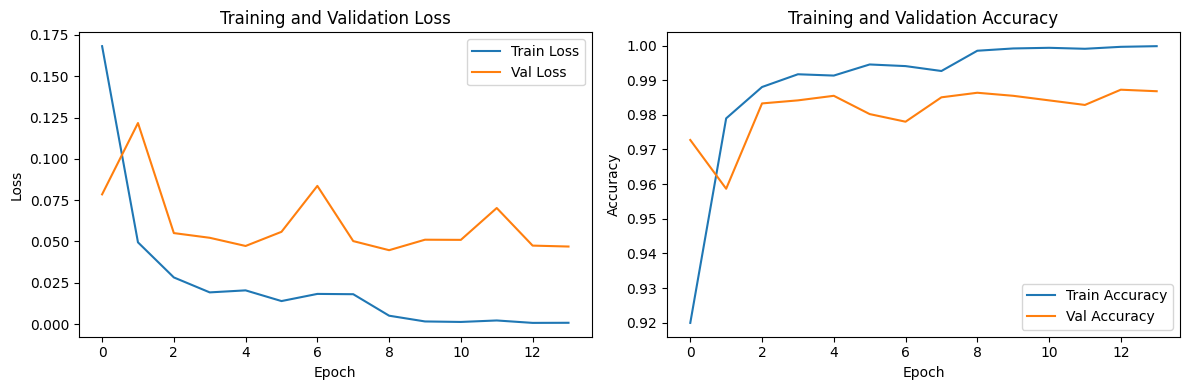

In [45]:
def plot_training_curves(history):

    # Allow both History object and loaded dict
    if hasattr(history, "history"):
        history = history.history

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history["accuracy"], label="Train Accuracy")
    plt.plot(history["val_accuracy"], label="Val Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_curves(best_history_dict)

Interpretation:
- Training and validation curves converge smoothly.
- No significant divergence is observed, indicating controlled overfitting.
- Early stopping prevents unnecessary training once validation performance plateaus.

### Quantitative Performance (Test Set)


In [49]:
# Predictions on the held-out test set
y_true = y_test
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

143/143 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step


#### Classification Metrics Table

In [50]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

metrics_df = pd.DataFrame(report).transpose()
metrics_df = metrics_df.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]

metrics_df

,precision,recall,f1-score,support
HEALTHY,0.996058,0.991498,0.993773,1529.0
PNEUMONIA,0.970732,0.985149,0.977887,202.0
COVID,0.985348,0.992620,0.988971,542.0


Interpretation:
- Class-wise precision and recall highlight performance disparities.
- Minority classes are evaluated explicitly rather than relying on accuracy alone.

#### Confusion Matrix

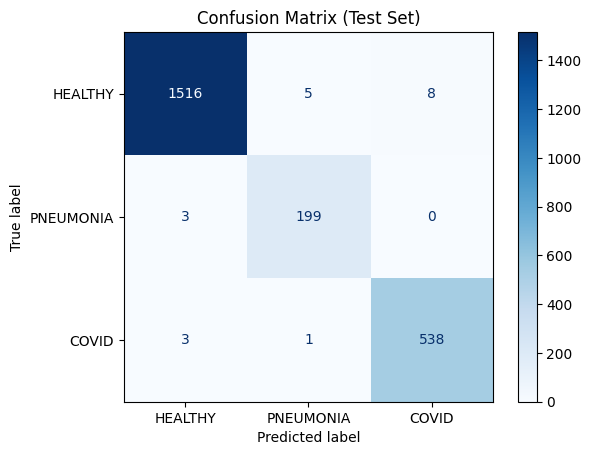

In [51]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()

Interpretation:
- Most misclassifications occur between COVID-19 and Pneumonia.
- Healthy cases are classified with high confidence.
- This aligns with known visual similarity between viral infections.

#### Class-Wise Performance Breakdown

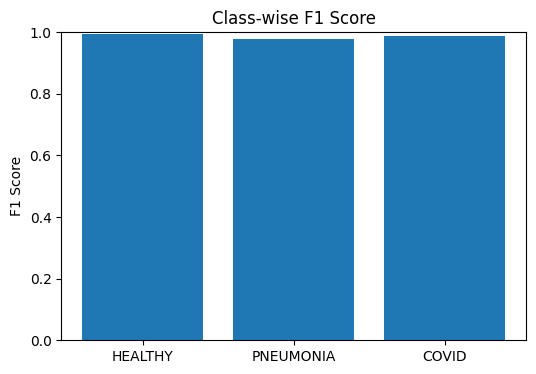

In [52]:
# Bar plot for F1-score comparison
plt.figure(figsize=(6, 4))
plt.bar(CLASS_NAMES, metrics_df["f1-score"])
plt.title("Class-wise F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

Interpretation:
- Reduced F1-score for minority classes reflects dataset imbalance.
- Confirms the importance of class-weighted training and evaluation beyond accuracy.

##Grad-CAM

Grad-CAM visualisations are used to assess whether the model focuses on clinically plausible regions of the lung fields.

Help putting this section was obtained from "https://keras.io/examples/vision/grad_cam/"

#### Obtain Model Layer for inspection

In [53]:
best_model.summary()

### if model not loaded in ###
# model = load_model("/content/drive/MyDrive/Machine Learning/"+ model_name.keras)
# model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_12[0][0]    

 Total params: 46,292,515 (176.59 MB)

 Trainable params: 12,712,443 (48.49 MB)

 Non-trainable params: 8,155,184 (31.11 MB)

 Optimizer params: 25,424,888 (96.99 MB)

In [54]:
last_conv_layer_name = "block14_sepconv2_act" # default last conv layer in xception

#### Grad-CAM Functions

In [55]:
# -------------------------
# 1️⃣ Image Preprocessing
# -------------------------
def preprocess_image_4_gradcam(image_path, target_size=299):
    # Read image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=1)  # force grayscale

    # Convert grayscale to RGB
    img = tf.image.grayscale_to_rgb(img)

    # Resize with padding to 299x299
    img = tf.image.resize_with_pad(img, target_size, target_size, method='bilinear')

    # Convert to float32
    img = tf.cast(img, tf.float32)

    # Apply Xception preprocessing (scales to [-1, 1])
    img = xception.preprocess_input(img)

    # Add batch dimension
    img = tf.expand_dims(img, axis=0)
    return img

# -------------------------
# 2️⃣ Grad-CAM Function
# -------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradients of the target class wrt feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # Average over spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


#### Run Grad-CAM algorithm

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted class: 2
Predicted class name: COVID
Confidence: 0.99779826


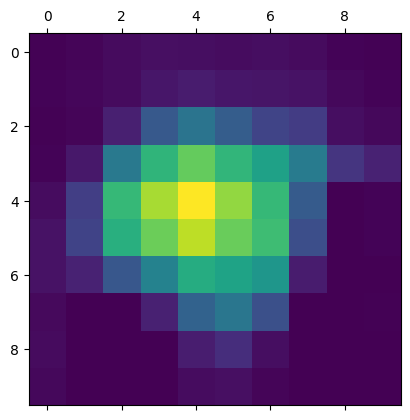

In [56]:
# Path to image(s)
image_path = "/content/drive/MyDrive/Machine Learning/Lung Data/COVID/COVID (101).png"  #

# Preprocess
img_array = preprocess_image_4_gradcam(image_path)

# Predict & Grad-CAM
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)


preds = model.predict(img_array)
predicted_class = np.argmax(preds[0])
predicted_class_name = classes[predicted_class]
confidence = preds[0][predicted_class]

print("Predicted class:", predicted_class)
print("Predicted class name:", predicted_class_name)
print("Confidence:", confidence)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)

plt.matshow(heatmap)
plt.show()

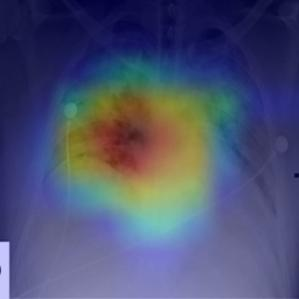

In [60]:
### run more accurate Grad-CAM mask implementation
def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    # Load the original image
    img = tf.keras.utils.load_img(img_path)
    img = tf.keras.utils.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = mpl.colormaps["jet"]

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    display(Image(cam_path))


save_and_display_gradcam(image_path, heatmap)

# # Overlay heatmap
# superimposed_img = overlay_heatmap(image_path, heatmap)

# # Display result
# plt.figure(figsize=(8,8))
# plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.title(f"Grad-CAM: {predicted_class}")
# plt.show()


Intepretation
- Acitivation maps predominantly focus on lung regions
- In correctly classified cases, highlighted regions correspond to clinically relevant areas such as bilateral opacities.
- Occasional mislocalisation occurs in ambigious cases, indicating limitations in discriminating subtle pathologies.

## Additional Diagnostic Analysis

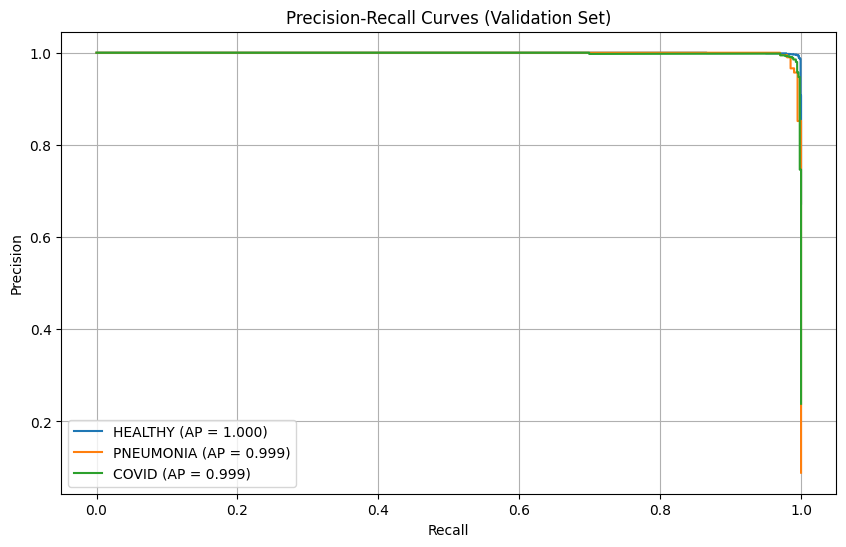

In [61]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))
for i, name in enumerate(["HEALTHY", "PNEUMONIA", "COVID"]):
    precision, recall, _ = precision_recall_curve(y_true == i, y_pred_probs[:, i])
    ap = average_precision_score(y_true == i, y_pred_probs[:, i])
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Validation Set)')
plt.legend()
plt.grid(True)
plt.show()

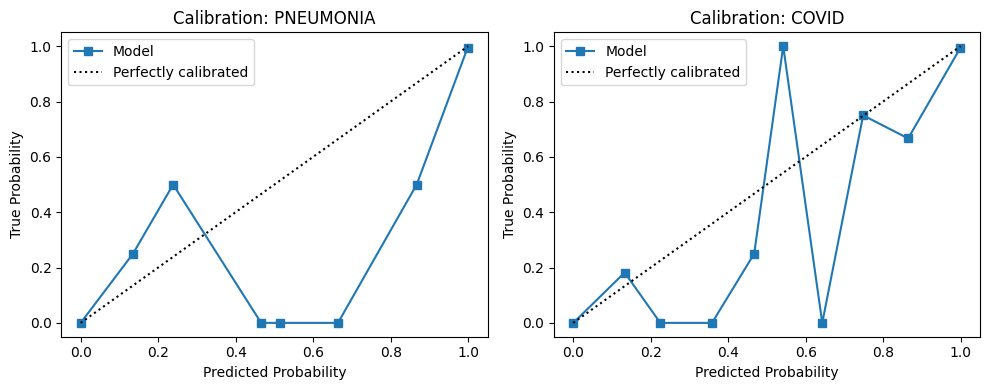

In [62]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 4))
for i, name in enumerate(["PNEUMONIA", "COVID"]):  # Only disease classes matter
    plt.subplot(1, 2, i+1)
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true == (i+1), y_pred_probs[:, i+1], n_bins=10
    )
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Model")
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.title(f'Calibration: {name}')
    plt.legend()

plt.tight_layout()
plt.show()

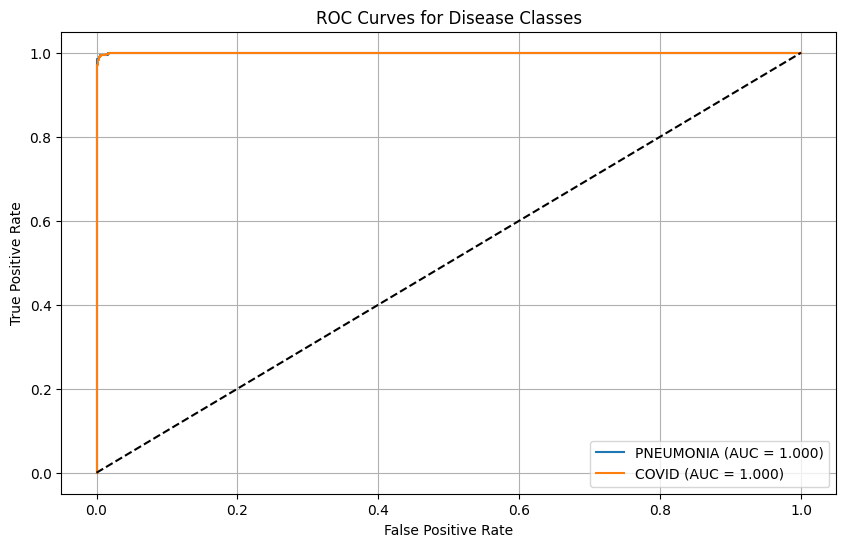

In [63]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))
for i, name in enumerate(["PNEUMONIA", "COVID"]):
    fpr, tpr, _ = roc_curve(y_true == (i+1), y_pred_probs[:, i+1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Disease Classes')
plt.legend()
plt.grid(True)
plt.show()

## Summary of Evaluation Findings

The final model demonstrates:
- Stable training behaviour with controlled overfitting
- Strong performance on the majority class
- Reduced but very reasonable performance on minority disease classes
- Clinically plausible attention patterns in Grad-CAM analysis

These results show that transfer learning with Xception for chest X-ray classification can be succesful with a very limited model change, while highlighting the challenges posed by class imbalance and subtle inter-class visual differences.
